# Low-Rank RNNs for Decision Making and Working Memory

## Overview

This notebook examines how low-rank connectivity supports two tasks. A
rank-one RNN first integrates noisy evidence and stores a binary decision.
We then compare two rank-two RNNs on delayed frequency comparison:

- **Network A** is randomly initialized and trained on one fixed schedule.
  It learns an oscillatory latent trajectory.
- **Network B** is initialized from the loading structure in the handout
  and trained with randomized delays. It develops a slow memory mode and a
  rapidly contracting mode.

For each network, we evaluate behavior, inspect the latent dynamics, fit a
Gaussian to the neuron loadings, and test both finite-network samples and
reduced mean-field circuits. The fixed-delay model is most accurate on its
training schedule; the variable-delay model remains accurate across
500–2000 ms delays.

## Setup and notation

All experiments use the repository's `LowRankRNN`:

$$
\tau \dot{x}
= -x + \frac{1}{N}MN^\top \tanh(x) + Iu,
\qquad
z = \frac{1}{N}w^\top\tanh(x).
$$

The loading matrices $M,N\in\mathbb{R}^{N\times R}$ give a recurrent
matrix of rank at most $R$. We use $R=1$ or $R=2$, with
$\Delta t/\tau=20/100=0.2$. Only $M$ and $N$ are trained; the input
vector $I$ and readout $w$ remain fixed.

### Conventions

- A standard Gaussian average has prefactor $1/\sqrt{2\pi}$.
- The rank-one variance depends on the filtered input $v$, not the
  instantaneous input $u$.
- Mean-field $\kappa$ is the coefficient in
  $x\approx M\kappa+Iv$, computed with a pseudoinverse. It is not the
  unit-axis projection $m^\top x/\lVert m\rVert$.
- The reduced circuit includes a readout so that it can be evaluated on
  the same task as the trained RNN.

In [1]:
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from low_rank_rnn import analysis, mean_field, plotting
from low_rank_rnn.data import perceptual_decision_making as decision_task
from low_rank_rnn.data import working_memory as memory_task
from low_rank_rnn.model import LowRankRNN, persistent_transient_rnn
from low_rank_rnn.training import (
    decision_accuracy,
    train_model,
    train_variable_delay,
)

plotting.set_plot_style()
BASE_SEED = 2026
NUM_UNITS = 512
TASK_MSE_THRESHOLD = 5e-3
NUM_GAUSSIAN_NETWORKS = 10
REPORT_FIGURE_DIRECTORY = Path("report/figures")


def save_report_figure(figure: plt.Figure, filename: str) -> Path:
    """Save a notebook figure as a vector PDF for the LaTeX report."""
    REPORT_FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
    output_path = REPORT_FIGURE_DIRECTORY / filename
    figure.savefig(output_path, format="pdf")
    return output_path


## 1. Rank-one perceptual decision task

### 1.1 Task

Each 75-step trial has a signed stimulus strength

$$
\bar{\mu} \in \pm 0.032\{1,2,4,8,16\},
\qquad
y=\operatorname{sign}(\bar{\mu}),
$$

with independent noise $\xi(t)\sim\mathcal{N}(0,0.03^2)$. The stimulus
is present for $5\leq t\leq45$, and the final 15 steps form the decision
window. The weakest stimulus is comparable to a single noise sample, so
the network must integrate evidence over time.

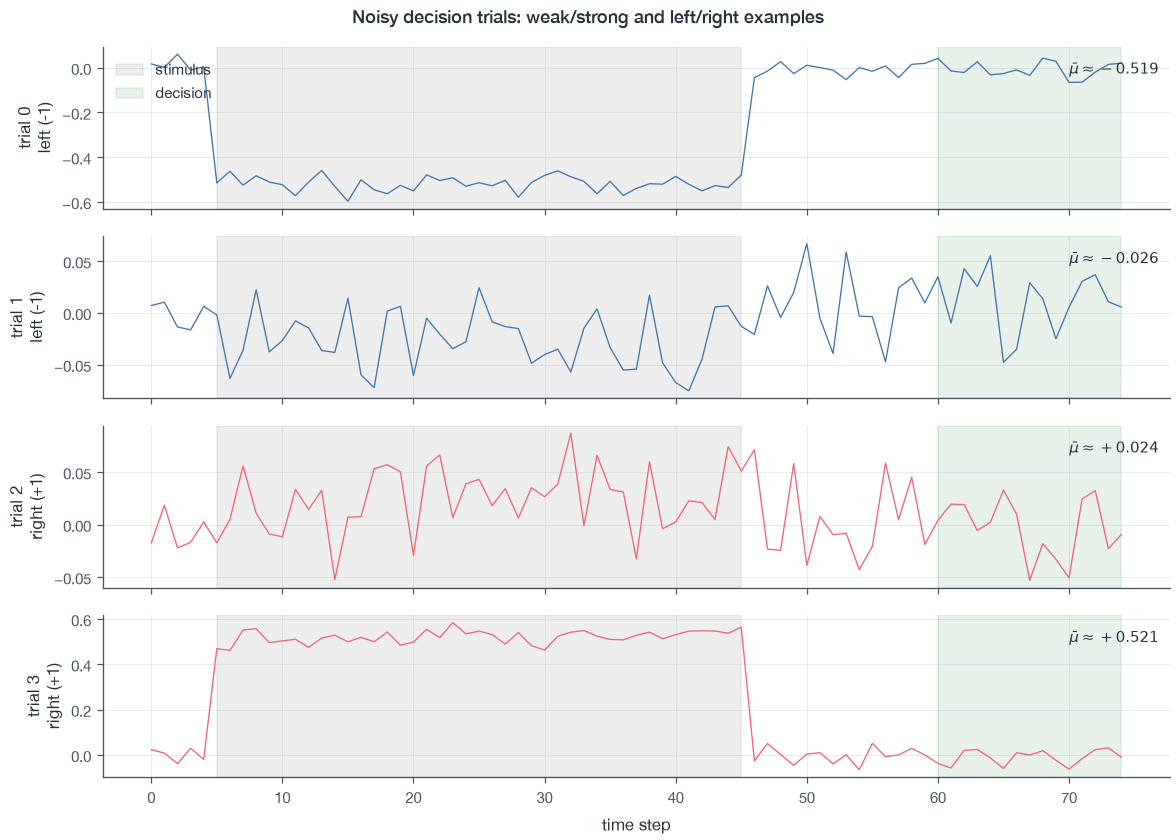

Allowed signed strengths: [-0.512 -0.256 -0.128 -0.064 -0.032  0.032  0.064  0.128  0.256  0.512]


In [2]:
preview_inputs, preview_labels = decision_task.generate_trials(
    num_trials=80,
    rng=np.random.default_rng(BASE_SEED),
)
preview_means = decision_task.mean_stimulus(preview_inputs)
preview_indices = decision_task.representative_trial_indices(
    preview_inputs,
    preview_labels,
)

rank1_decision_trials_figure, _ = plotting.plot_decision_trials(
    preview_inputs[preview_indices],
    preview_labels[preview_indices],
    mean_stimuli=preview_means[preview_indices],
)
save_report_figure(
    rank1_decision_trials_figure,
    "rank1-decision-task-trials.pdf",
)
plt.show()

print(
    "Allowed signed strengths:",
    np.round(np.sort(decision_task.STIMULUS_STRENGTHS), 3),
)


### 1.2 Train and evaluate

The recurrent update is computed as $m[n^\top\phi(x)/N]$, without
constructing the $N\times N$ matrix. Training uses Adam with learning
rate $5\times10^{-3}$, batches of 32, and MSE over the final 15 steps.
One epoch is one pass over the fixed training set.

In [3]:
RANK1_DECISION_STEPS = 15
RANK1_TRAIN_TRIALS = 200
RANK1_EPOCHS = 300
BATCH_SIZE = 32
LEARNING_RATE = 5e-3

rank1_train_inputs, rank1_train_labels = decision_task.generate_trials(
    num_trials=RANK1_TRAIN_TRIALS,
    rng=np.random.default_rng(BASE_SEED + 1),
)
rank1_test_inputs, rank1_test_labels = decision_task.generate_trials(
    num_trials=256,
    rng=np.random.default_rng(BASE_SEED + 2),
)

torch.manual_seed(BASE_SEED)
rank1_model = LowRankRNN(n_units=NUM_UNITS, rank=1)
fixed_input_before = rank1_model.I.clone()
fixed_readout_before = rank1_model.w.clone()
rank1_losses = train_model(
    rank1_model,
    torch.as_tensor(rank1_train_inputs, dtype=torch.float32),
    torch.as_tensor(rank1_train_labels, dtype=torch.float32),
    epochs=RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=RANK1_DECISION_STEPS,
    log_every=100,
)

# Orient the sign-indeterminate factors so positive latent activity maps
# to the +1 readout.
with torch.no_grad():
    m_centered = rank1_model.m[:, 0] - rank1_model.m[:, 0].mean()
    w_centered = rank1_model.w - rank1_model.w.mean()
    if torch.dot(m_centered, w_centered) < 0:
        rank1_model.m[:, 0].mul_(-1)
        rank1_model.n[:, 0].mul_(-1)

rank1_outputs, rank1_states = analysis.run_model(rank1_model, rank1_test_inputs)
rank1_decisions = analysis.decision_values(
    rank1_outputs,
    RANK1_DECISION_STEPS,
)
rank1_test_mse, _ = analysis.regression_metrics(
    rank1_decisions,
    rank1_test_labels,
)
rank1_accuracy = float(
    np.mean(np.where(rank1_decisions >= 0, 1, -1) == rank1_test_labels)
)
rank1_updates = RANK1_EPOCHS * ceil(RANK1_TRAIN_TRIALS / BATCH_SIZE)

assert rank1_losses[-1] < 5e-2
assert torch.equal(rank1_model.I, fixed_input_before)
assert torch.equal(rank1_model.w, fixed_readout_before)

print(f"Optimizer updates:      {rank1_updates}")
print(f"Final training loss:    {rank1_losses[-1]:.6f}  (target < 0.05)")
print(f"Held-out decision MSE: {rank1_test_mse:.6f}")
print(f"Held-out sign accuracy:{rank1_accuracy:8.1%}")


Epoch 100: loss=0.000164


Epoch 200: loss=0.000087


Epoch 300: loss=0.000069
Optimizer updates:      2100
Final training loss:    0.000069  (target < 0.05)
Held-out decision MSE: 0.000034
Held-out sign accuracy:  100.0%


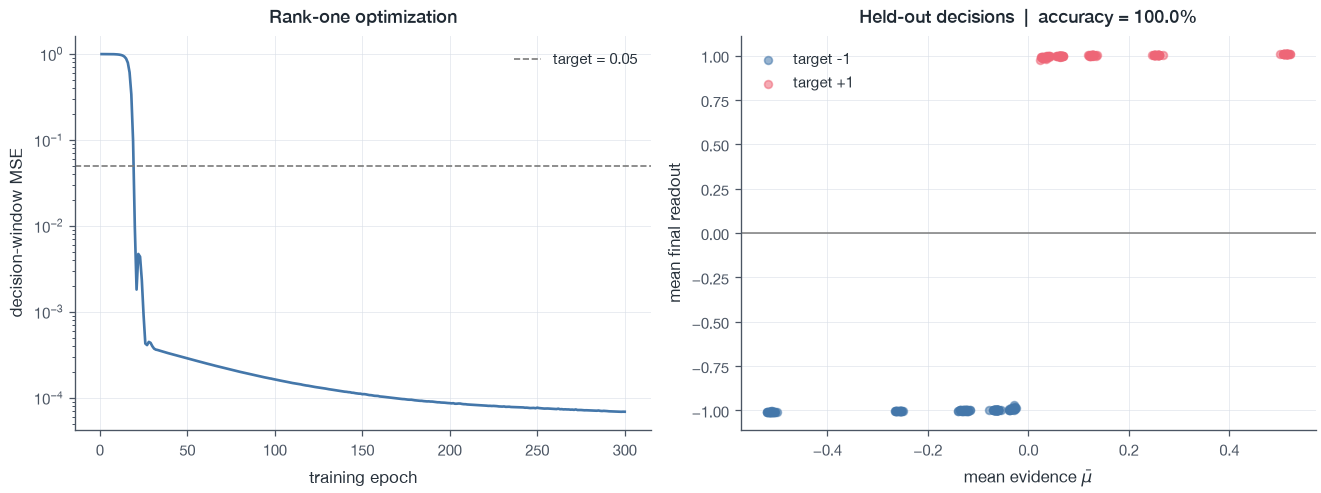

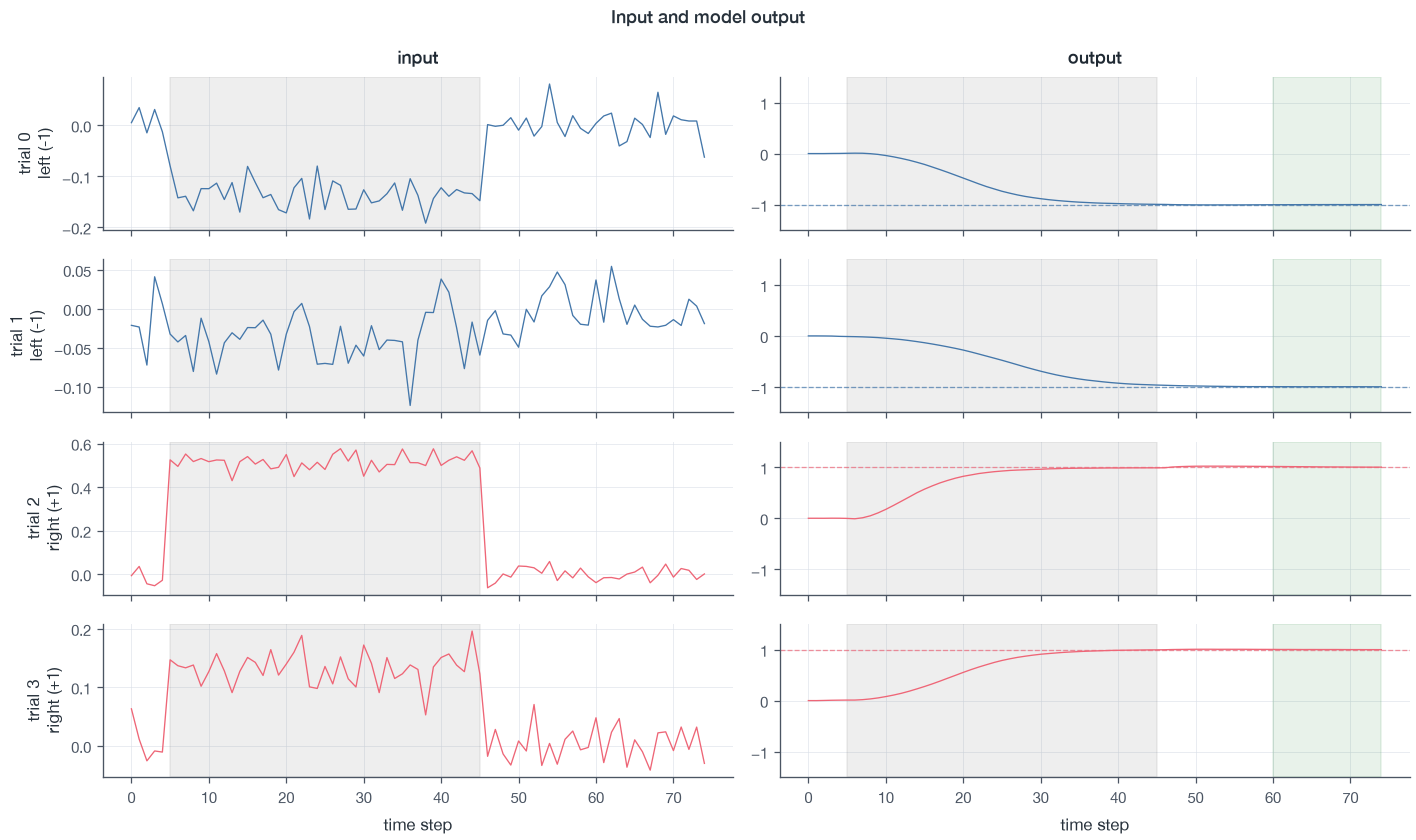

In [4]:
stimulus_estimates = decision_task.mean_stimulus(rank1_test_inputs)
rank1_training_summary_figure, _ = plotting.plot_decision_summary(
    rank1_losses,
    stimulus_estimates,
    rank1_decisions,
    rank1_test_labels,
    accuracy=rank1_accuracy,
    loss_threshold=5e-2,
)
save_report_figure(
    rank1_training_summary_figure,
    "rank1-training-summary.pdf",
)
plt.show()

positive_examples = np.flatnonzero(rank1_test_labels > 0)[:2]
negative_examples = np.flatnonzero(rank1_test_labels < 0)[:2]
rank1_examples = np.concatenate((negative_examples, positive_examples))
rank1_input_output_figure, _ = plotting.plot_trial_outputs(
    rank1_test_inputs[rank1_examples],
    rank1_test_labels[rank1_examples],
    rank1_outputs[rank1_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
save_report_figure(
    rank1_input_output_figure,
    "rank1-input-output-examples.pdf",
)
plt.show()

rank1_training_examples = np.concatenate((positive_examples, negative_examples))
rank1_training_input_output_figure, _ = plotting.plot_trial_outputs(
    rank1_test_inputs[rank1_training_examples],
    rank1_test_labels[rank1_training_examples],
    rank1_outputs[rank1_training_examples],
    decision_steps=RANK1_DECISION_STEPS,
)
save_report_figure(
    rank1_training_input_output_figure,
    "rank1-training-input-output.pdf",
)
plt.close(rank1_training_input_output_figure)


### 1.3 Connectivity in loading space

Each neuron is one point in four-dimensional loading space
$(I,n,m,w)$. Three covariances connect input to output:

1. $\operatorname{Cov}(n,I)$ couples the input to the recurrent latent.
2. $\operatorname{Cov}(m,n)$ provides recurrent feedback.
3. $\operatorname{Cov}(m,w)$ couples the latent to the readout.

The rank-one factorization has an arbitrary sign:
$m\to-m,\ n\to-n$ leaves $J=mn^\top/N$ unchanged. We orient the
factors so that $\operatorname{Cov}(m,w)>0$; this makes positive latent
activity correspond to the $+1$ choice.

The handout uses
$(\sigma_{mn},\sigma_{nI},\sigma_{mw})=(1.4,2.6,2.1)$. This trained
network gives approximately $(1.59,0.65,2.04)$: recurrent and readout
coupling are similar, while the fitted input coupling is weaker.

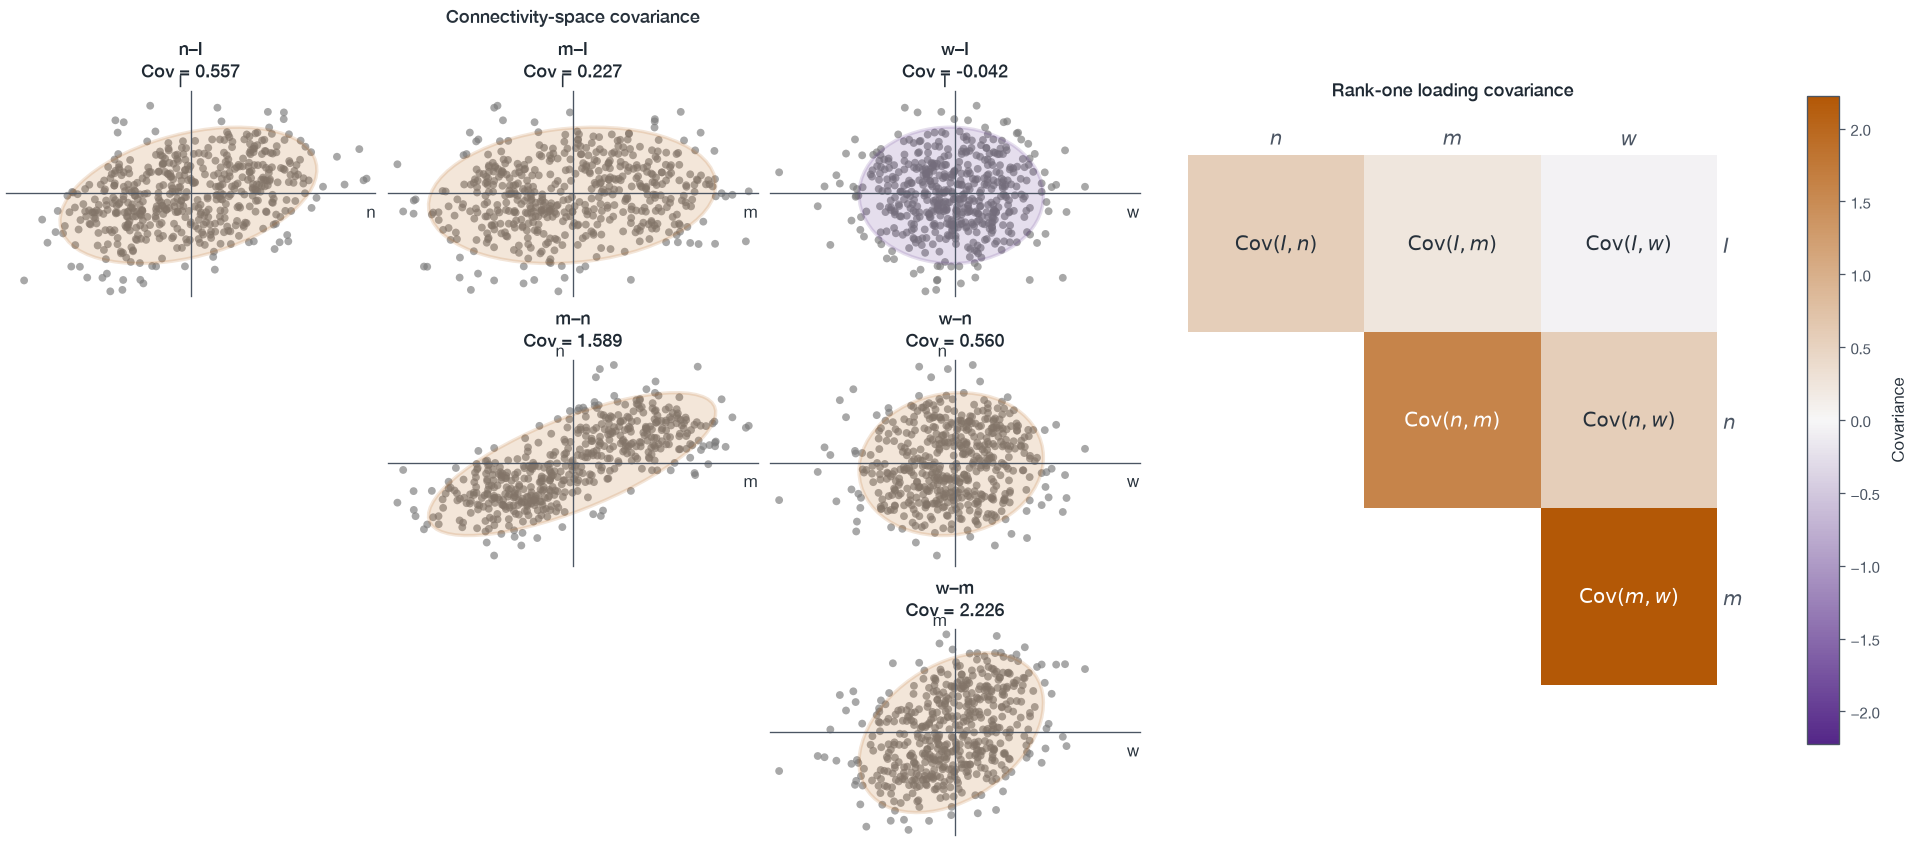

{'Cov(n, I)': 0.55559180843174,
 'Cov(m, n)': 1.586221464696318,
 'Cov(m, w)': 2.22194114418914}

In [5]:
rank1_vectors = analysis.connectivity_vectors(rank1_model)
rank1_names = tuple(rank1_vectors)
rank1_loading_mean, rank1_loading_covariance = analysis.fit_loading_gaussian(
    rank1_vectors
)

rank1_loading_space_figure, _, _ = plotting.plot_connectivity_summary(
    rank1_vectors,
    rank1_names,
    rank1_loading_covariance,
    row_names=("I", "n", "m"),
    column_names=("n", "m", "w"),
    covariance_title="Rank-one loading covariance",
)
save_report_figure(
    rank1_loading_space_figure,
    "rank1-loading-space-covariance.pdf",
)
plt.show()

rank1_couplings = analysis.named_covariances(
    rank1_names,
    rank1_loading_covariance,
    (("n", "I"), ("m", "n"), ("m", "w")),
)
rank1_couplings


### 1.4 Gaussian resampling

We fit a four-dimensional Gaussian to the 128 neuron loadings and sample
ten new, untrained networks. This tests whether the fitted loading
statistics are sufficient for the task. At finite $N$, a sample only
approximates the fitted covariance, so performance can vary across draws.

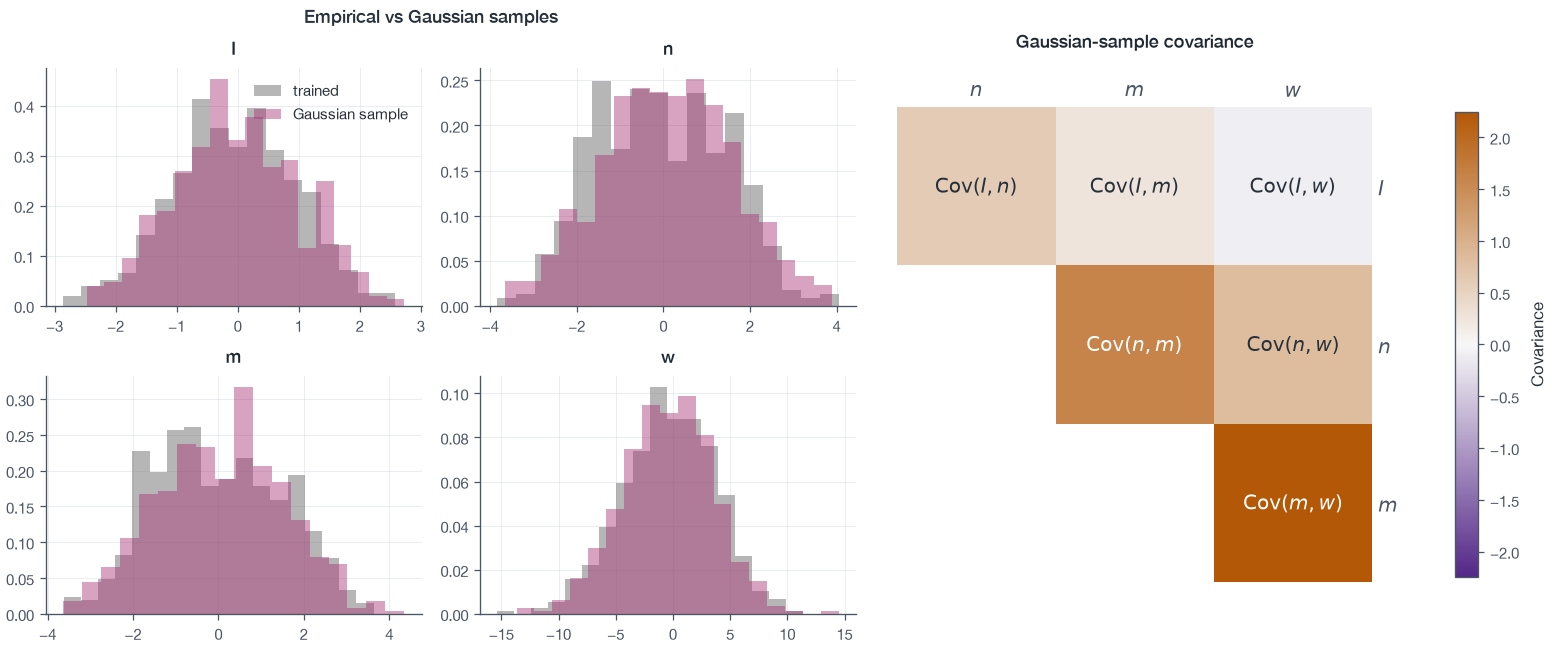

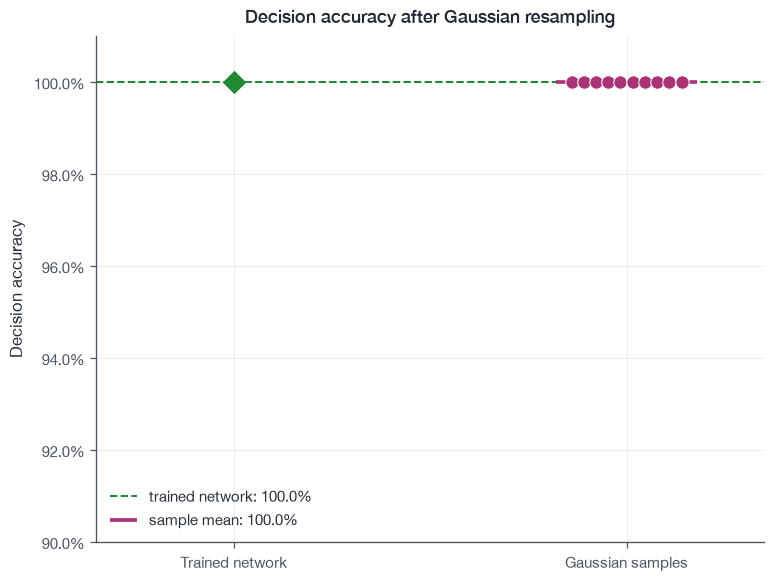

One-sample relative covariance error: 3.8%
Gaussian-network accuracy, mean [range]: 100.0% [100.0%, 100.0%]


In [6]:
rank1_sampled_vectors, rank1_sampled_covariance = (
    analysis.sample_loading_vectors(
        rank1_names,
        rank1_loading_mean,
        rank1_loading_covariance,
        num_samples=NUM_UNITS,
        rng=np.random.default_rng(BASE_SEED + 10),
    )
)
rank1_sampled_networks = analysis.sample_low_rank_rnns(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 11),
)
rank1_sampled_accuracies = np.array(
    [
        decision_accuracy(
            network,
            torch.as_tensor(rank1_test_inputs, dtype=torch.float32),
            torch.as_tensor(rank1_test_labels),
            decision_steps=RANK1_DECISION_STEPS,
        )
        for network in rank1_sampled_networks
    ]
)
rank1_covariance_error = np.linalg.norm(
    rank1_sampled_covariance - rank1_loading_covariance
) / np.linalg.norm(rank1_loading_covariance)

plotting.plot_gaussian_sampling_summary(
    rank1_vectors,
    rank1_sampled_vectors,
    rank1_names,
    rank1_sampled_covariance,
    rank1_accuracy,
    rank1_sampled_accuracies,
    covariance_title="Gaussian-sample covariance",
)
plt.show()

print(f"One-sample relative covariance error: {rank1_covariance_error:.1%}")
print(
    "Gaussian-network accuracy, mean [range]: "
    f"{rank1_sampled_accuracies.mean():.1%} "
    f"[{rank1_sampled_accuracies.min():.1%}, {rank1_sampled_accuracies.max():.1%}]"
)


### 1.5 Low-dimensional activity

Starting from $x(0)=0$, the state cannot leave
$\operatorname{span}\{m,I\}$: recurrence points along $m$, input along
$I$, and the leak adds no new direction. The activity should therefore
be at most two-dimensional.

We check this with PCA on the centered state matrix. The first plot shows
explained variance; the second projects the trial trajectories onto the
first two principal components. PCA may rotate the axes within the plane,
so the components need not align with $m$ and $I$ separately.

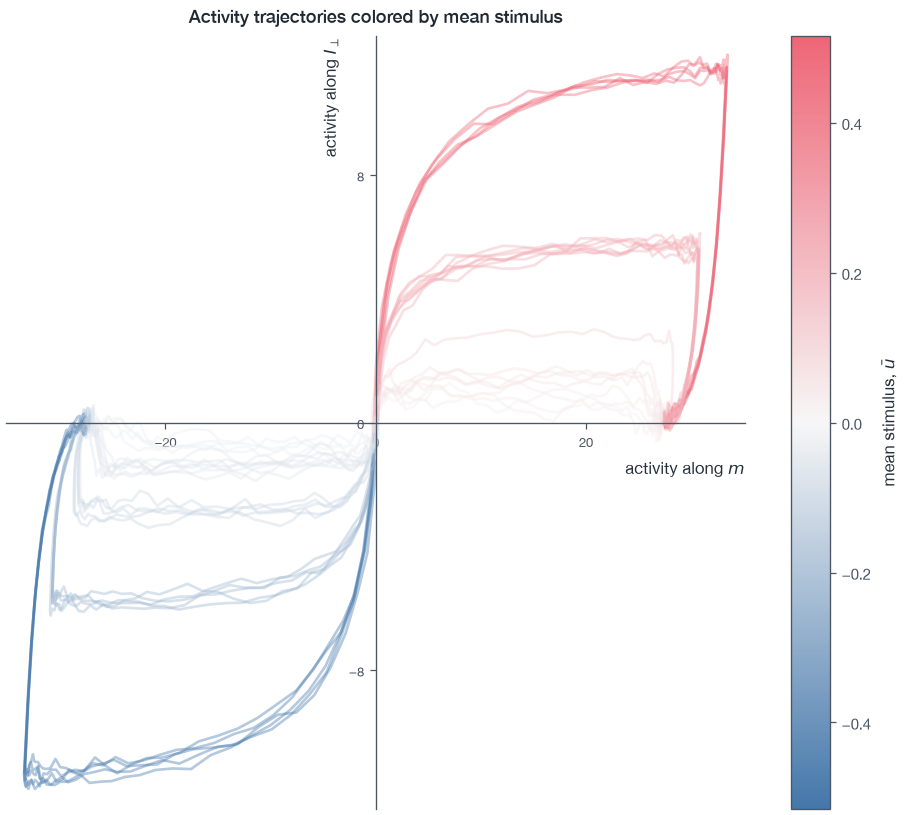

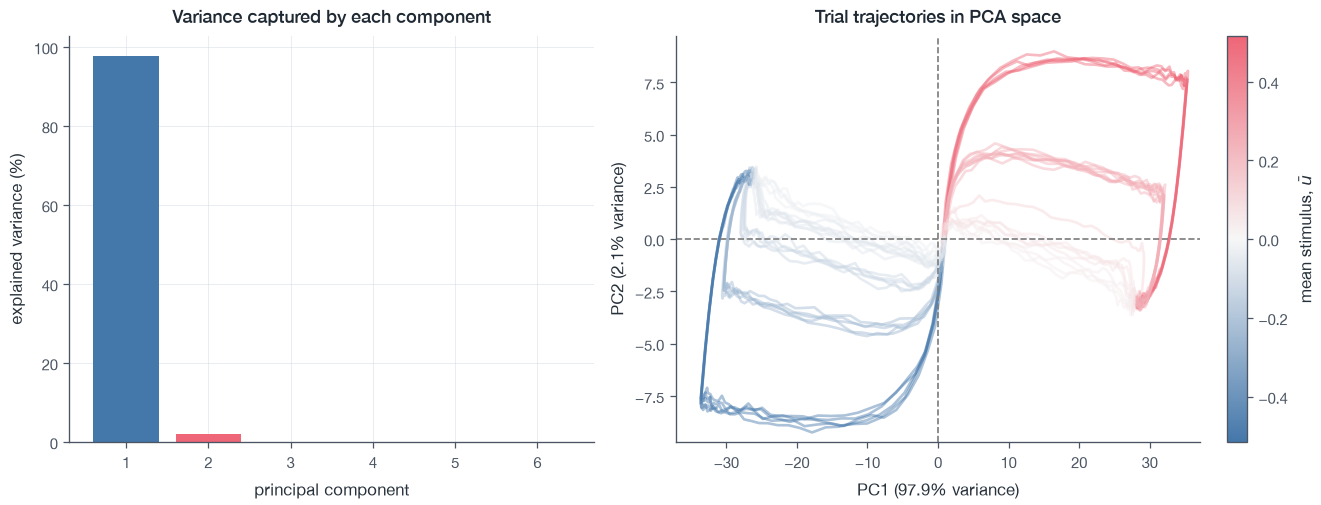

Variance explained by the first two PCs: 100.00%


In [7]:
rank1_projected = analysis.project_rank_one_activity(
    torch.as_tensor(rank1_states, dtype=torch.float32),
    rank1_model,
)
trajectory_subset = np.linspace(0, len(rank1_projected) - 1, 48, dtype=int)
rank1_latent_trajectories_figure, _ = (
    plotting.plot_activity_trajectories_by_stimulus(
        rank1_projected[trajectory_subset],
        stimulus_estimates[trajectory_subset],
    )
)
save_report_figure(
    rank1_latent_trajectories_figure,
    "rank1-latent-trajectories.pdf",
)
plt.show()

(
    rank1_explained_variance,
    _,
    rank1_pca_trajectories,
) = analysis.principal_component_analysis(rank1_states)
rank1_pca_summary_figure, _ = plotting.plot_pca_summary(
    rank1_explained_variance,
    rank1_pca_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
save_report_figure(
    rank1_pca_summary_figure,
    "rank1-pca-summary.pdf",
)
plt.show()
print(
    "Variance explained by the first two PCs: "
    f"{rank1_explained_variance[:2].sum():.2%}"
)


### 1.6 Gaussian mean-field reduction

For jointly Gaussian loadings and

$$
h_i = I_i v+\sum_r m_{ir}\kappa_r,
$$

Stein's lemma gives the latent dynamics, in units of $\tau$,

$$
\dot{\boldsymbol{\kappa}}
=-\boldsymbol{\kappa}
+\boldsymbol{\mu}_n\langle\tanh h\rangle
+\operatorname{Cov}(\boldsymbol{n},h)
  \langle\operatorname{sech}^2 h\rangle,
\qquad
\dot v=-v+u.
$$

The readout has the same form with $n$ replaced by $w$. For
zero-mean, orthogonal rank-one loadings this becomes

$$
\dot\kappa=-\kappa+g(\Delta)
\left[\sigma_{mn}\kappa+\sigma_{nI}v\right],
\qquad
\Delta^2=\sigma_m^2\kappa^2+\sigma_I^2v^2.
$$

The implementation keeps the fitted means and the full covariance, and
the same function is used for rank two.

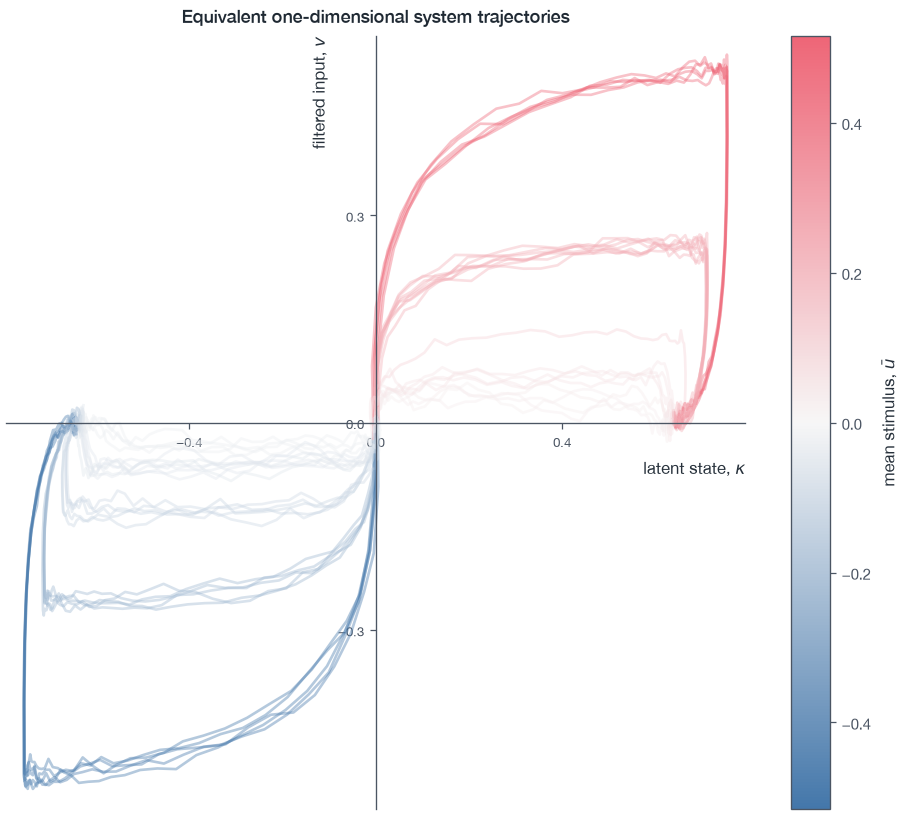

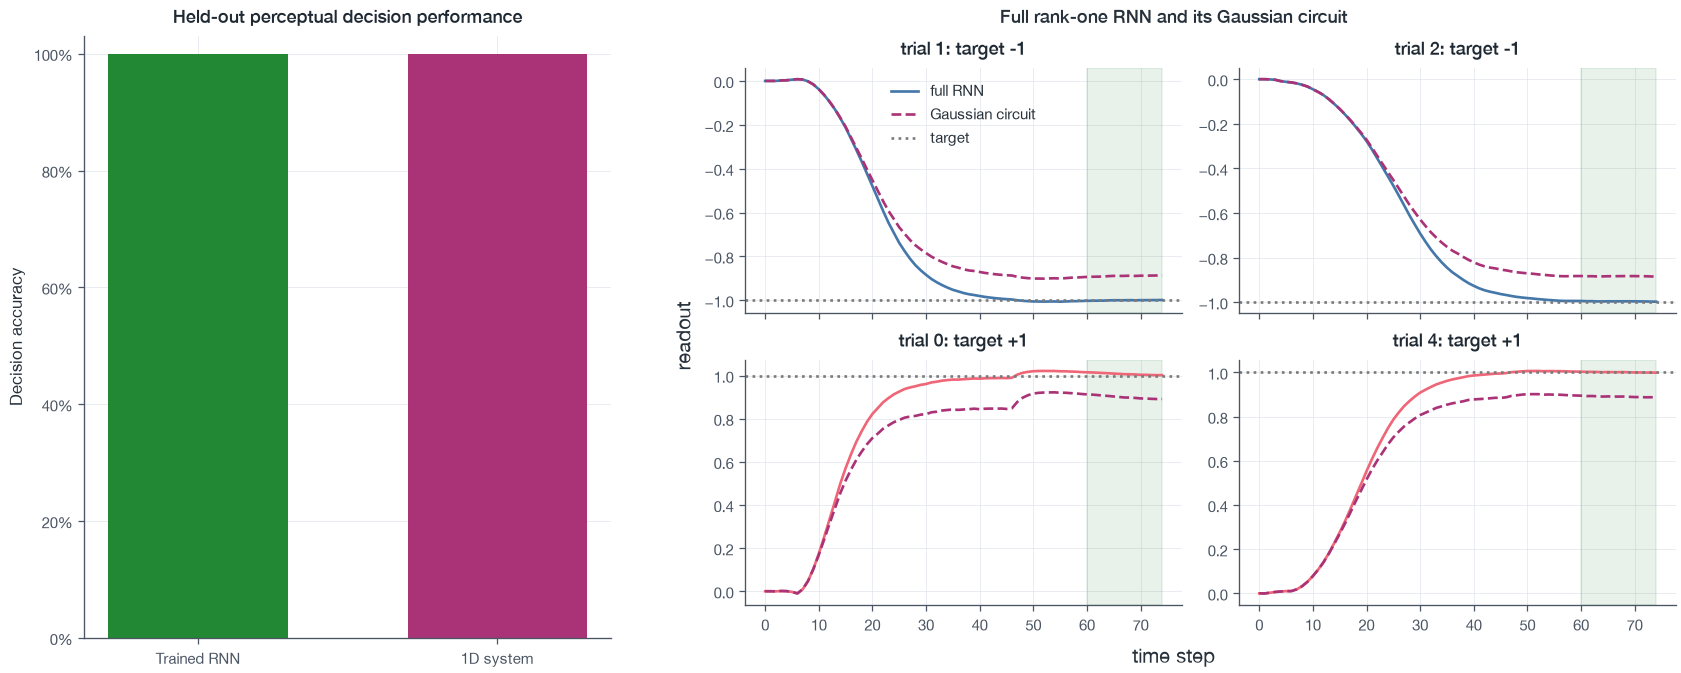

Gaussian-circuit sign accuracy: 100.0%


In [8]:
(
    rank1_reduced_outputs,
    rank1_reduced_kappa,
    rank1_filtered_input,
) = mean_field.simulate_gaussian_circuit(
    rank1_test_inputs,
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
    step_size=rank1_model.step_size,
)
rank1_reduced_decisions = analysis.decision_values(
    rank1_reduced_outputs,
    RANK1_DECISION_STEPS,
)
rank1_reduced_accuracy = float(
    np.mean(
        np.where(rank1_reduced_decisions >= 0, 1, -1)
        == rank1_test_labels
    )
)

reduced_trajectories = np.dstack(
    (rank1_reduced_kappa[..., 0], rank1_filtered_input)
)
plotting.plot_reduced_system_trajectories(
    reduced_trajectories[trajectory_subset],
    stimulus_estimates[trajectory_subset],
)
plt.show()
rank1_reduced_summary_figure = plt.figure(figsize=(14, 5.6), layout="constrained")
accuracy_panel, comparison_panel = rank1_reduced_summary_figure.subfigures(
    1,
    2,
    width_ratios=(1, 1.65),
    wspace=0.06,
)
plotting.plot_reduced_system_accuracy(
    rank1_accuracy,
    rank1_reduced_accuracy,
    axis=accuracy_panel.subplots(),
)
plotting.plot_output_comparison(
    rank1_outputs,
    rank1_reduced_outputs,
    rank1_test_labels,
    rank1_examples,
    decision_steps=RANK1_DECISION_STEPS,
    axes=comparison_panel.subplots(2, 2, sharex=True),
)
plt.show()

print(f"Gaussian-circuit sign accuracy: {rank1_reduced_accuracy:.1%}")


### 1.7 Fixed points

At zero input, let $f(\kappa)=\dot\kappa$. We locate roots of
$f$ from a dense grid and classify each one by its slope:
$f'(\kappa)<0$ is stable and $f'(\kappa)>0$ is unstable.

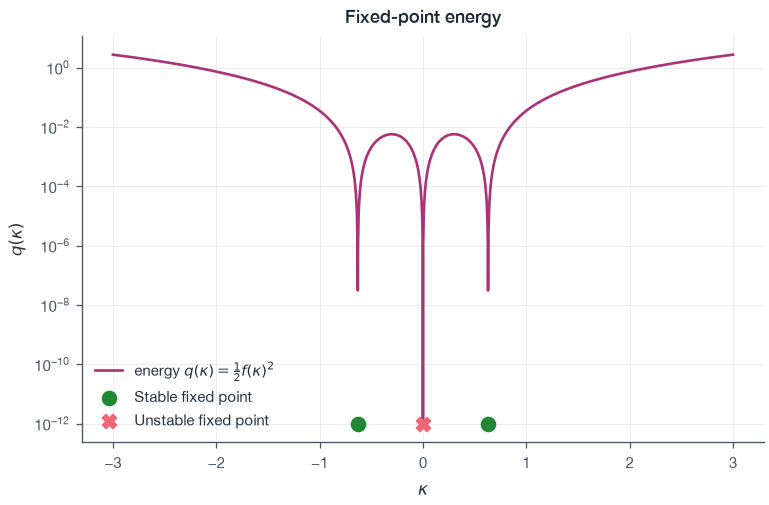

kappa=-0.6304  slope=-0.571  stable
kappa=+0.0000  slope=+0.587  unstable
kappa=+0.6304  slope=-0.571  stable


In [9]:
(
    kappa_grid,
    flow_grid,
    fixed_points,
    fixed_point_slopes,
) = mean_field.rank_one_fixed_points(
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
)
fixed_point_stability = np.where(
    fixed_point_slopes < 0,
    "stable",
    "unstable",
)
fixed_point_residuals = mean_field.gaussian_latent_flow(
    fixed_points[:, None],
    np.zeros(len(fixed_points)),
    rank1_names,
    rank1_loading_mean,
    rank1_loading_covariance,
)[:, 0]
assert np.max(np.abs(fixed_point_residuals)) < 1e-5

plotting.plot_fixed_points(
    kappa_grid,
    flow_grid,
    fixed_points,
    fixed_point_slopes,
)
plt.show()

for point, slope, stability in zip(
    fixed_points,
    fixed_point_slopes,
    fixed_point_stability,
):
    print(f"kappa={point:+.4f}  slope={slope:+.3f}  {stability}")


Two stable fixed points store the two choices, with an unstable boundary
between them. An exact-value integrator would instead require a continuum
of marginal fixed points so that the stimulus magnitude, not only its
sign, could persist.

## 2. Rank-two working-memory task

Both networks learn the normalized frequency difference

$$
y=\frac{f_1-f_2}{24},
$$

but under different training schedules:

- **Network A** is randomly initialized and trained at one fixed delay.
- **Network B** is initialized with the handout's persistent/transient
  structure and trained across randomized delays.

For each network, we evaluate behavior, identify the latent modes, fit its
post-training loading Gaussian, and compare finite Gaussian samples with
full-covariance and diagonal mean-field circuits. These reconstructions
use each model's own task protocol. Section 2.4 evaluates both trained
models on identical trials.

### 2.1 Task

The fixed task uses all $7\times7$ ordered frequency pairs from 10 to
34 Hz. The final five steps form the decision window.

In [10]:
MEMORY_DECISION_STEPS = memory_task.FIXED_DECISION_STEPS
MEMORY_TRIAL_LENGTH = memory_task.FIXED_TRIAL_STEPS
memory_grid_pairs = memory_task.frequency_pair_grid()
memory_grid_inputs, memory_grid_targets = memory_task.make_fixed_delay_trials(
    memory_grid_pairs
)
target_matrix = memory_grid_targets.reshape(
    len(memory_task.FREQUENCIES),
    len(memory_task.FREQUENCIES),
)

outside_stimuli = np.ones(MEMORY_TRIAL_LENGTH, dtype=bool)
for start, stop in (
    memory_task.FIXED_FIRST_WINDOW,
    memory_task.FIXED_SECOND_WINDOW,
):
    outside_stimuli[start:stop] = False
assert memory_grid_inputs.shape == (49, MEMORY_TRIAL_LENGTH)
assert np.all(memory_grid_inputs[:, outside_stimuli] == 0)


### 2.2 Network A: fixed-delay training

#### Train and evaluate

Rank-two and rank-one models are trained on the same fixed-delay trials.
The rank-one model serves as a capacity control.

Epoch 200: loss=0.115592


Epoch 400: loss=0.004947


Epoch 600: loss=0.000391


Network A rank-two MSE: 0.000373
Matched rank-one MSE:   0.111737


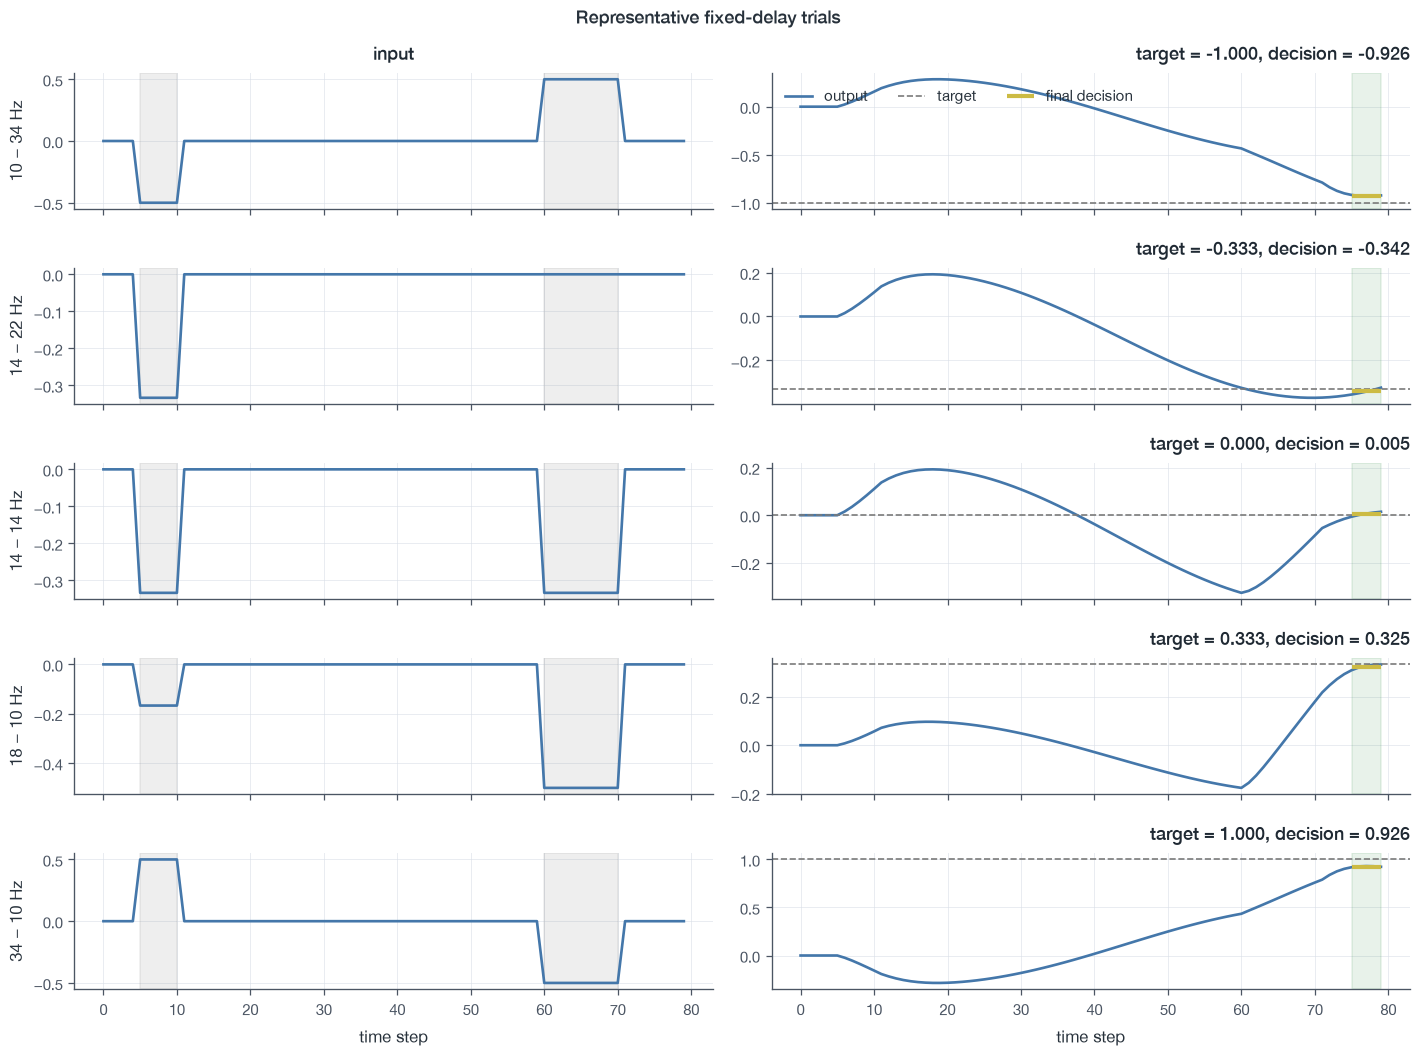

In [11]:
MEMORY_TRAIN_TRIALS = 200
MEMORY_RANK2_EPOCHS = 600
MEMORY_RANK1_EPOCHS = 600

_, memory_train_inputs, memory_train_targets = (
    memory_task.sample_fixed_delay_trials(
        MEMORY_TRAIN_TRIALS,
        rng=np.random.default_rng(BASE_SEED),
    )
)

torch.manual_seed(BASE_SEED)
oscillatory_model = LowRankRNN(NUM_UNITS, rank=2)
oscillatory_losses = train_model(
    oscillatory_model,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK2_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=200,
)

torch.manual_seed(BASE_SEED + 1)
fixed_rank1_control = LowRankRNN(NUM_UNITS, rank=1)
fixed_rank1_losses = train_model(
    fixed_rank1_control,
    torch.as_tensor(memory_train_inputs),
    torch.as_tensor(memory_train_targets),
    epochs=MEMORY_RANK1_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    decision_steps=MEMORY_DECISION_STEPS,
    log_every=None,
)

oscillatory_grid_outputs, _ = analysis.run_model(
    oscillatory_model,
    memory_grid_inputs,
)
oscillatory_grid_decisions = analysis.decision_values(
    oscillatory_grid_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_mse, _ = analysis.regression_metrics(
    oscillatory_grid_decisions,
    memory_grid_targets,
)

fixed_rank1_outputs, _ = analysis.run_model(
    fixed_rank1_control,
    memory_grid_inputs,
)
fixed_rank1_decisions = analysis.decision_values(
    fixed_rank1_outputs,
    MEMORY_DECISION_STEPS,
)
fixed_rank1_mse, _ = analysis.regression_metrics(
    fixed_rank1_decisions,
    memory_grid_targets,
)

assert oscillatory_mse < TASK_MSE_THRESHOLD
print(f"Network A rank-two MSE: {oscillatory_mse:.6f}")
print(f"Matched rank-one MSE:   {fixed_rank1_mse:.6f}")

representative_pairs = np.array(
    ((10, 34), (14, 22), (14, 14), (18, 10), (34, 10))
)
representative_inputs, representative_targets = (
    memory_task.make_fixed_delay_trials(representative_pairs)
)
representative_outputs, _ = analysis.run_model(
    oscillatory_model,
    representative_inputs,
)
plotting.plot_memory_trials(
    representative_pairs,
    representative_inputs,
    representative_targets,
    representative_outputs,
    first_window=memory_task.FIXED_FIRST_WINDOW,
    second_window=memory_task.FIXED_SECOND_WINDOW,
    decision_steps=MEMORY_DECISION_STEPS,
)
plt.show()


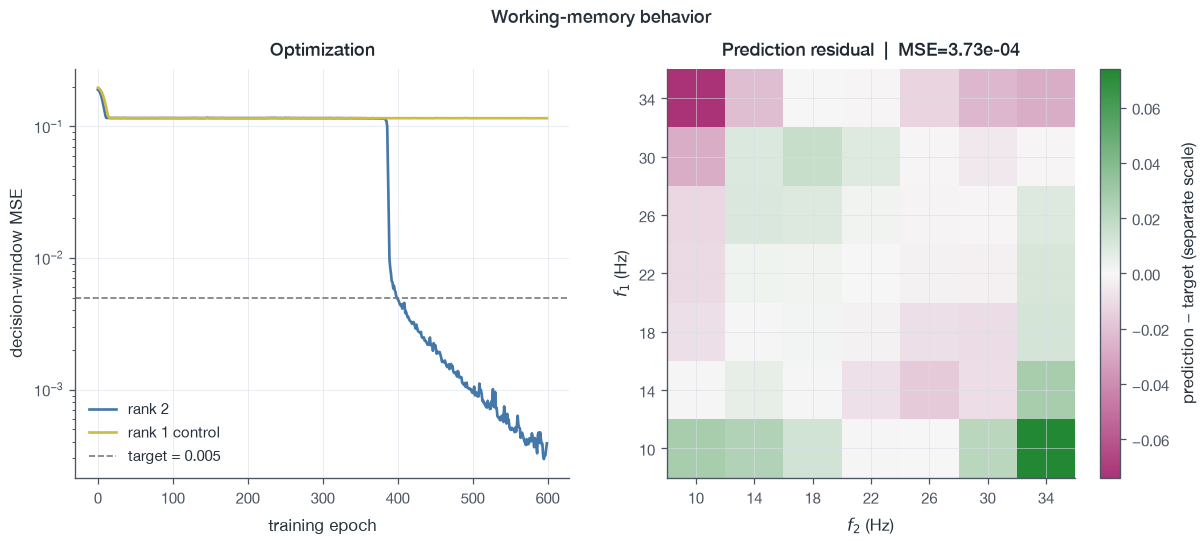

In [12]:
plotting.plot_memory_behavior(
    oscillatory_losses,
    fixed_rank1_losses,
    target_matrix,
    oscillatory_grid_decisions,
    memory_task.FREQUENCIES,
    mse=oscillatory_mse,
    loss_threshold=TASK_MSE_THRESHOLD,
)
plt.show()


#### Latent dynamics

We transform Network A to an SVD basis, which preserves $MN^\top$, and
inspect the recurrent overlap eigenvalues and projected trajectories.

In [13]:
oscillatory_canonical, oscillatory_reconstruction_error = (
    analysis.svd_canonical_model(oscillatory_model)
)
oscillatory_m = oscillatory_canonical.m.detach().numpy()
oscillatory_n = oscillatory_canonical.n.detach().numpy()
oscillatory_overlap_eigenvalues = np.linalg.eigvals(
    analysis.connectivity_overlap(oscillatory_m, oscillatory_n)
)

assert oscillatory_reconstruction_error < 1e-5
print(
    "Recurrent overlap eigenvalues:",
    np.round(oscillatory_overlap_eigenvalues, 3),
)


Recurrent overlap eigenvalues: [1.041+0.282j 1.041-0.282j]


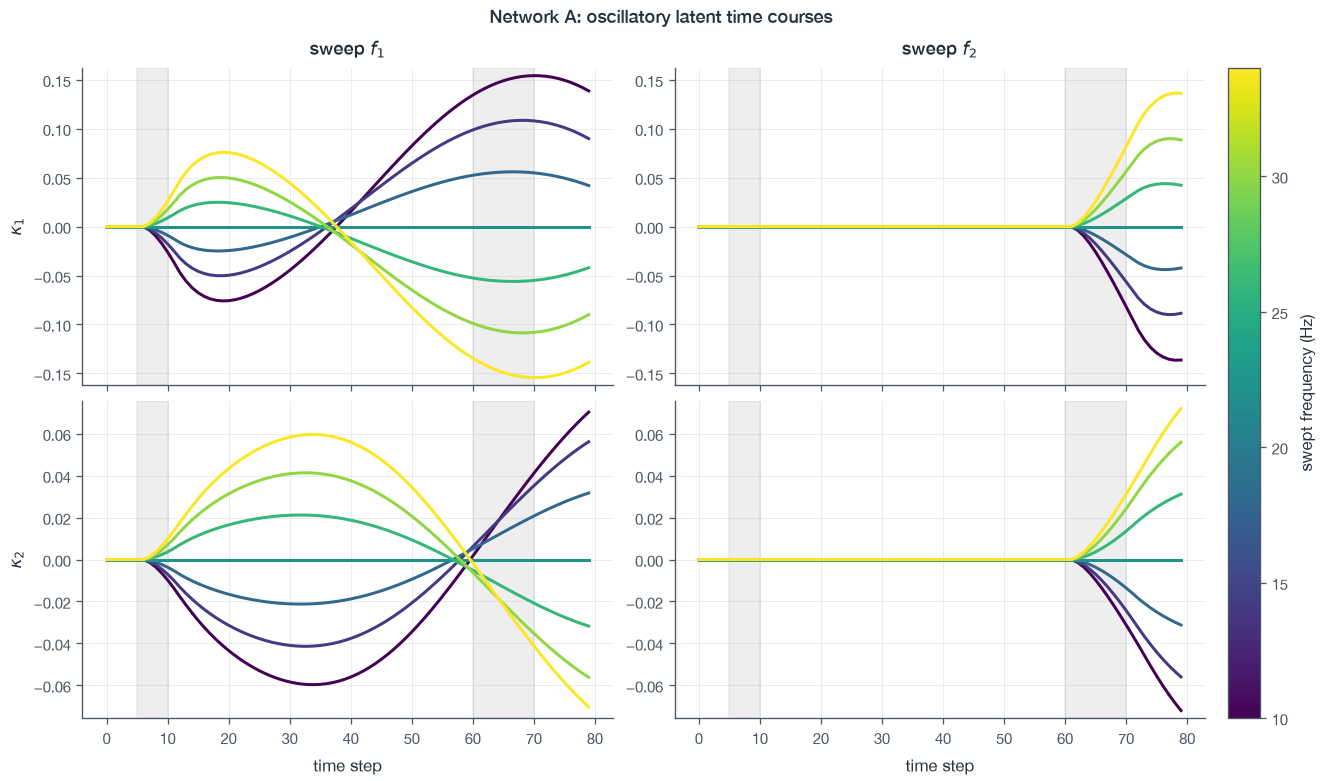

In [14]:
first_sweep_pairs, second_sweep_pairs = memory_task.frequency_sweeps()
first_sweep_inputs, _ = memory_task.make_fixed_delay_trials(
    first_sweep_pairs
)
second_sweep_inputs, _ = memory_task.make_fixed_delay_trials(
    second_sweep_pairs
)
oscillatory_basis = np.column_stack(
    (oscillatory_m, oscillatory_canonical.I.detach().numpy())
)
_, first_sweep_states, first_sweep_coordinates = (
    analysis.simulate_and_project(
        oscillatory_canonical,
        first_sweep_inputs,
        oscillatory_basis,
    )
)
_, _, second_sweep_coordinates = analysis.simulate_and_project(
    oscillatory_canonical,
    second_sweep_inputs,
    oscillatory_basis,
)

plotting.plot_latent_sweeps(
    first_sweep_coordinates[..., :2],
    second_sweep_coordinates[..., :2],
    memory_task.FREQUENCIES,
    time_values=np.arange(MEMORY_TRIAL_LENGTH),
    window_spans=(
        (
            memory_task.FIXED_FIRST_WINDOW[0],
            memory_task.FIXED_FIRST_WINDOW[1] - 1,
        ),
        (
            memory_task.FIXED_SECOND_WINDOW[0],
            memory_task.FIXED_SECOND_WINDOW[1] - 1,
        ),
    ),
    column_titles=(r"sweep $f_1$", r"sweep $f_2$"),
    row_labels=(r"$\kappa_1$", r"$\kappa_2$"),
    title="Network A: oscillatory latent time courses",
)
plt.show()


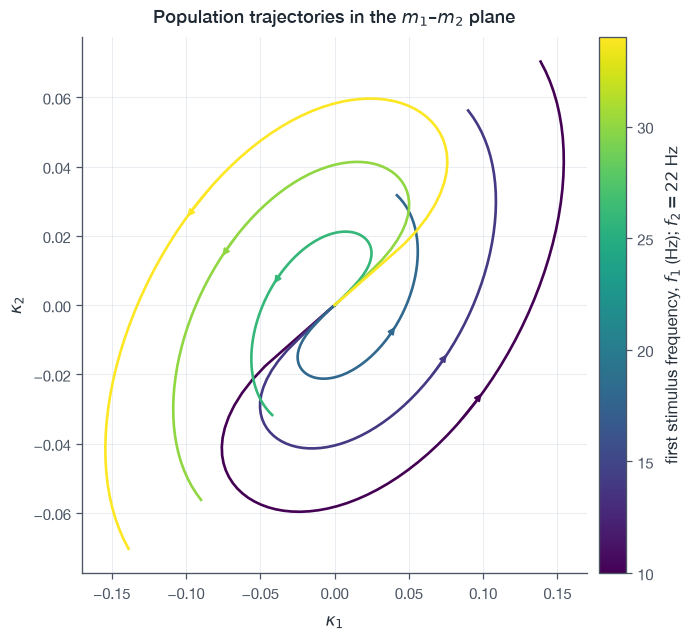

Median delay-flow eigenvalues (1/tau): [0.029 0.029]


In [15]:
plotting.plot_latent_plane(
    first_sweep_coordinates[..., :2],
    memory_task.FREQUENCIES,
    colorbar_label=(
        r"first stimulus frequency, $f_1$ (Hz); $f_2=22$ Hz"
    ),
)
plt.show()

delay_probe_states = first_sweep_states[
    :, memory_task.FIXED_SECOND_WINDOW[0] - 1
]
delay_eigenvalues = analysis.latent_jacobian_eigenvalues(
    oscillatory_canonical,
    delay_probe_states,
)
median_delay_decay = np.median(
    np.sort(delay_eigenvalues.real, axis=1),
    axis=0,
)[::-1]
print(
    "Median delay-flow eigenvalues (1/tau):",
    np.round(median_delay_decay, 3),
)


The two latent coordinates oscillate out of phase. The overlap eigenvalues
$0.989\pm0.223i$, together with median delay-flow real parts of
$-0.021$, are consistent with a slowly decaying rotation. Network A uses
this rotation as a clock for the fixed schedule.

**How the oscillation solves the task.** Define the normalized stimulus
value $\tilde f_i=(f_i-22)/24$, which is exactly the scalar amplitude
presented to the network. The target can then be written as
$y=\tilde f_1-\tilde f_2$.

The next plot is not the raw readout trace from one trial. At each blank
delay on the horizontal axis, we move the second stimulus and decision
window together, run all 49 frequency pairs, average the readout over the
final five decision steps, and fit

$$
\bar{z}(d)=a(d)+\beta_1(d)\tilde f_1+\beta_2(d)\tilde f_2.
$$

Thus $\beta_1$ measures how strongly the decision uses the remembered
first stimulus, while $\beta_2$ measures how strongly it uses the recent
second stimulus. The task requires $\beta_1=+1$ and $\beta_2=-1$.

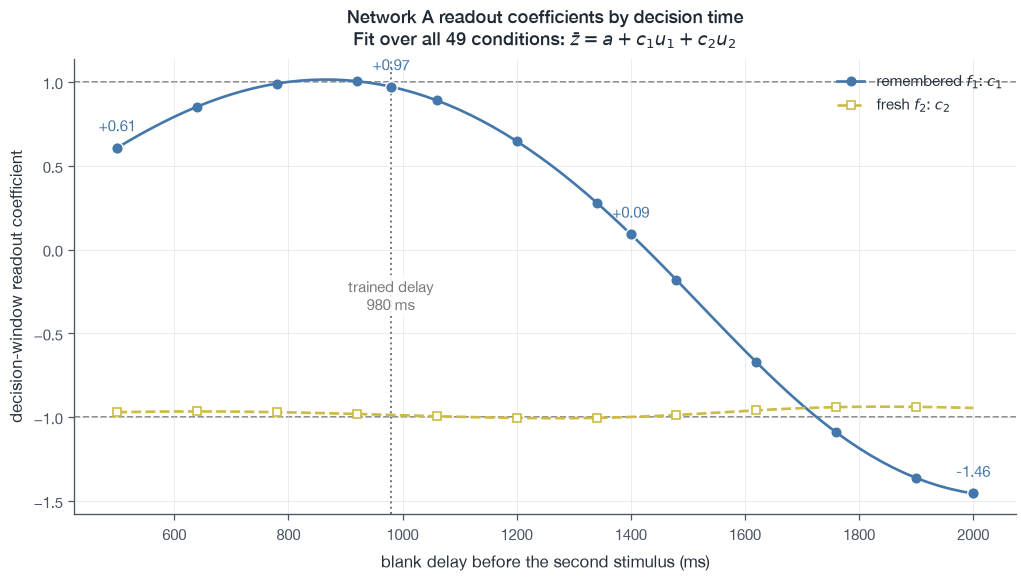

In [16]:
readout_delay_steps = memory_task.DELAYS.copy()
trained_delay_steps = (
    memory_task.FIXED_SECOND_WINDOW[0]
    - memory_task.FIXED_FIRST_WINDOW[1]
)
readout_design = np.column_stack(
    (
        np.ones(len(memory_grid_pairs)),
        memory_task.stimulus_amplitudes(memory_grid_pairs),
    )
)

readout_coefficients = []
for delay in readout_delay_steps:
    second_start = memory_task.FIXED_FIRST_WINDOW[1] + int(delay)
    delayed_inputs, _ = memory_task.make_fixed_delay_trials(
        memory_grid_pairs,
        second_start=second_start,
    )
    delayed_outputs, _ = analysis.run_model(
        oscillatory_model,
        delayed_inputs,
    )
    delayed_decisions = analysis.decision_values(
        delayed_outputs,
        MEMORY_DECISION_STEPS,
    )
    fitted_weights = np.linalg.lstsq(
        readout_design,
        delayed_decisions,
        rcond=None,
    )[0]
    readout_coefficients.append(fitted_weights[1:])
readout_coefficients = np.asarray(readout_coefficients)

plotting.plot_readout_coefficients(
    readout_delay_steps,
    readout_coefficients,
    trained_delay=trained_delay_steps,
    annotation_delays=(25, trained_delay_steps, 70, 100),
)
plt.show()


The second-stimulus coefficient $\beta_2$ remains near $-1$ at every
delay because the second stimulus always occurs at the same offset before
the decision. The remembered-stimulus coefficient $\beta_1$ changes with
the oscillator's phase: it is close to $+1$ at the trained delay of 49
time steps, but later crosses zero and becomes negative. Thus Network A
computes $\tilde f_1-\tilde f_2$ only when the fixed readout samples the
rotating memory at the expected step.

#### Gaussian reconstruction

We fit a six-dimensional Gaussian in the SVD basis, then test finite
$N=128$ samples, the full-covariance mean-field circuit, and the
diagonal circuit on the fixed-delay grid.

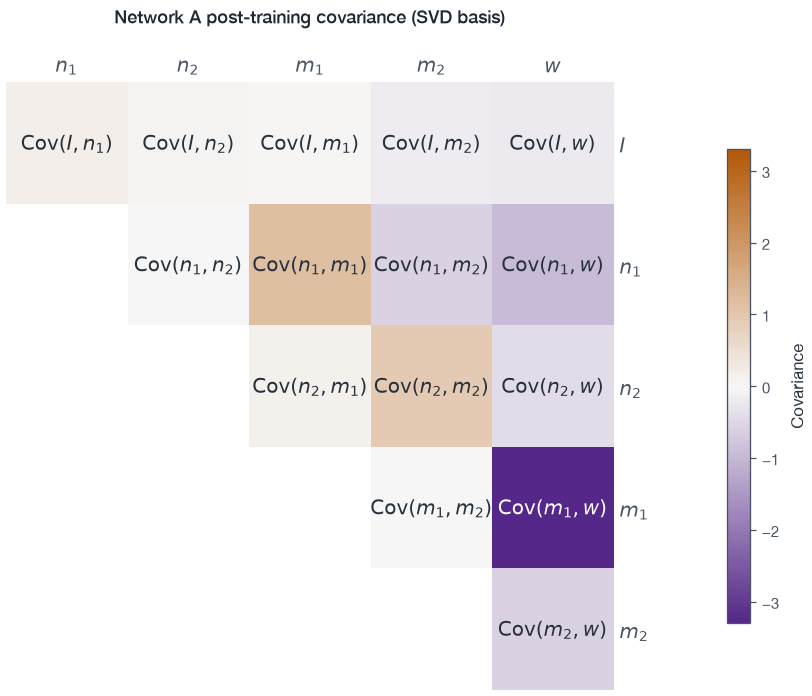

In [17]:
oscillatory_vectors = analysis.connectivity_vectors(
    oscillatory_canonical
)
oscillatory_names = tuple(oscillatory_vectors)
(
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
) = analysis.fit_loading_gaussian(oscillatory_vectors)

plotting.plot_connectivity_covariance(
    oscillatory_names,
    oscillatory_loading_covariance,
    title="Network A post-training covariance (SVD basis)",
)
plt.show()


In [18]:
oscillatory_sampled_networks = analysis.sample_low_rank_rnns(
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 21),
)
oscillatory_sampled_mses = analysis.network_regression_mses(
    oscillatory_sampled_networks,
    memory_grid_inputs,
    memory_grid_targets,
    decision_steps=MEMORY_DECISION_STEPS,
)

print(
    "Finite Gaussian RNN MSE, median [range]: "
    f"{np.median(oscillatory_sampled_mses):.4f} "
    f"[{oscillatory_sampled_mses.min():.4f}, "
    f"{oscillatory_sampled_mses.max():.4f}]"
)


Finite Gaussian RNN MSE, median [range]: 0.0839 [0.0044, 1.2020]


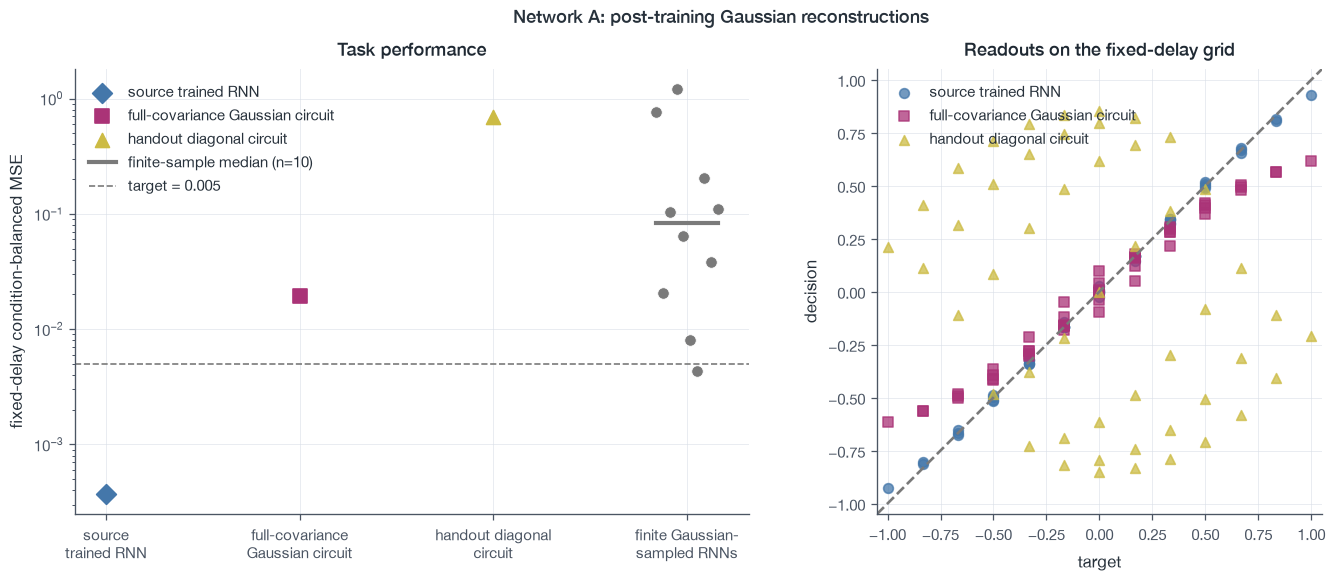

Source / full / diagonal MSE: [3.73000e-04 1.95040e-02 6.94787e-01]


In [19]:
oscillatory_reduced_outputs, _, _ = mean_field.simulate_gaussian_circuit(
    memory_grid_inputs,
    oscillatory_names,
    oscillatory_loading_mean,
    oscillatory_loading_covariance,
    step_size=oscillatory_canonical.step_size,
)
oscillatory_reduced_decisions = analysis.decision_values(
    oscillatory_reduced_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_reduced_mse, _ = (
    analysis.regression_metrics(
        oscillatory_reduced_decisions,
        memory_grid_targets,
    )
)

oscillatory_diagonal_outputs, _, _ = (
    mean_field.simulate_diagonal_circuit(
        memory_grid_inputs,
        oscillatory_names,
        oscillatory_loading_covariance,
        step_size=oscillatory_canonical.step_size,
    )
)
oscillatory_diagonal_decisions = analysis.decision_values(
    oscillatory_diagonal_outputs,
    MEMORY_DECISION_STEPS,
)
oscillatory_diagonal_mse, _ = (
    analysis.regression_metrics(
        oscillatory_diagonal_decisions,
        memory_grid_targets,
    )
)

plotting.plot_gaussian_pipeline(
    oscillatory_mse,
    oscillatory_reduced_mse,
    oscillatory_diagonal_mse,
    oscillatory_sampled_mses,
    memory_grid_targets,
    oscillatory_grid_decisions,
    oscillatory_reduced_decisions,
    oscillatory_diagonal_decisions,
    threshold=TASK_MSE_THRESHOLD,
    title="Network A: post-training Gaussian reconstructions",
    score_label="fixed-delay condition-balanced MSE",
    readout_title="Readouts on the fixed-delay grid",
)
plt.show()

print(
    "Source / full / diagonal MSE:",
    np.round(
        (
            oscillatory_mse,
            oscillatory_reduced_mse,
            oscillatory_diagonal_mse,
        ),
        6,
    ),
)


Finite Gaussian samples vary widely (median MSE $0.501$). The
full-covariance circuit is much closer to the trained network
($0.018$ versus $0.0008$) than the diagonal circuit ($0.985$), but
it still misses the $0.005$ task threshold. The cross-mode covariance
is important for reconstructing the rotation.

### 2.3 Network B: variable-delay training

Network B starts from the handout's structured loadings and is trained on
dense frequencies with randomized 500–2000 ms delays. The handout
coefficients are used only for initialization; the following
reconstructions use the trained network's fitted statistics.

#### Train and evaluate

In [20]:
PERSISTENT_TRANSIENT_SEED = 2032
PERSISTENT_TRANSIENT_EPOCHS = 12
DENSE_FREQUENCIES = np.arange(10, 35)
DELAY_CURRICULUM = (
    np.arange(25, 51),
    np.arange(25, 76),
    np.arange(25, 101),
)

persistent_model = persistent_transient_rnn(
    NUM_UNITS,
    seed=PERSISTENT_TRANSIENT_SEED,
)
persistent_losses = train_variable_delay(
    persistent_model,
    DELAY_CURRICULUM,
    rng=np.random.default_rng(PERSISTENT_TRANSIENT_SEED),
    frequencies=DENSE_FREQUENCIES,
    num_trials=640,
    epochs_per_stage=PERSISTENT_TRANSIENT_EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    max_gradient_norm=1.0,
)

print(f"Final training MSE: {persistent_losses[-1]:.4g}")


Final training MSE: 0.002097


In [21]:
probe_delays = np.array((25, 50, 75, 100))
(
    persistent_probe_mses,
    _,
    persistent_probe_decisions_by_delay,
) = analysis.variable_delay_metrics(
    lambda inputs: analysis.run_model(persistent_model, inputs)[0],
    memory_grid_pairs,
    probe_delays,
)

assert persistent_probe_mses.max() < TASK_MSE_THRESHOLD
print(
    "Decision MSE at 500, 1000, 1500, 2000 ms:",
    np.round(persistent_probe_mses, 4),
)


Decision MSE at 500, 1000, 1500, 2000 ms: [0.0018 0.0018 0.0021 0.0025]


#### Latent dynamics

The real-mode basis orders the recurrent modes by loop gain. A gain near
one gives a slow memory mode; a smaller gain gives a contracting mode.

In [22]:
persistent_m, persistent_n, persistent_overlap_values = (
    analysis.real_overlap_modes(persistent_model)
)
persistent_overlap = analysis.connectivity_overlap(
    persistent_m,
    persistent_n,
)

print("Loop gains:", np.round(persistent_overlap_values, 3))
print(
    "Zero-state flow eigenvalues (1/tau):",
    np.round(persistent_overlap_values - 1, 3),
)


Loop gains: [ 1.013 -0.229]
Zero-state flow eigenvalues (1/tau): [ 0.013 -1.229]


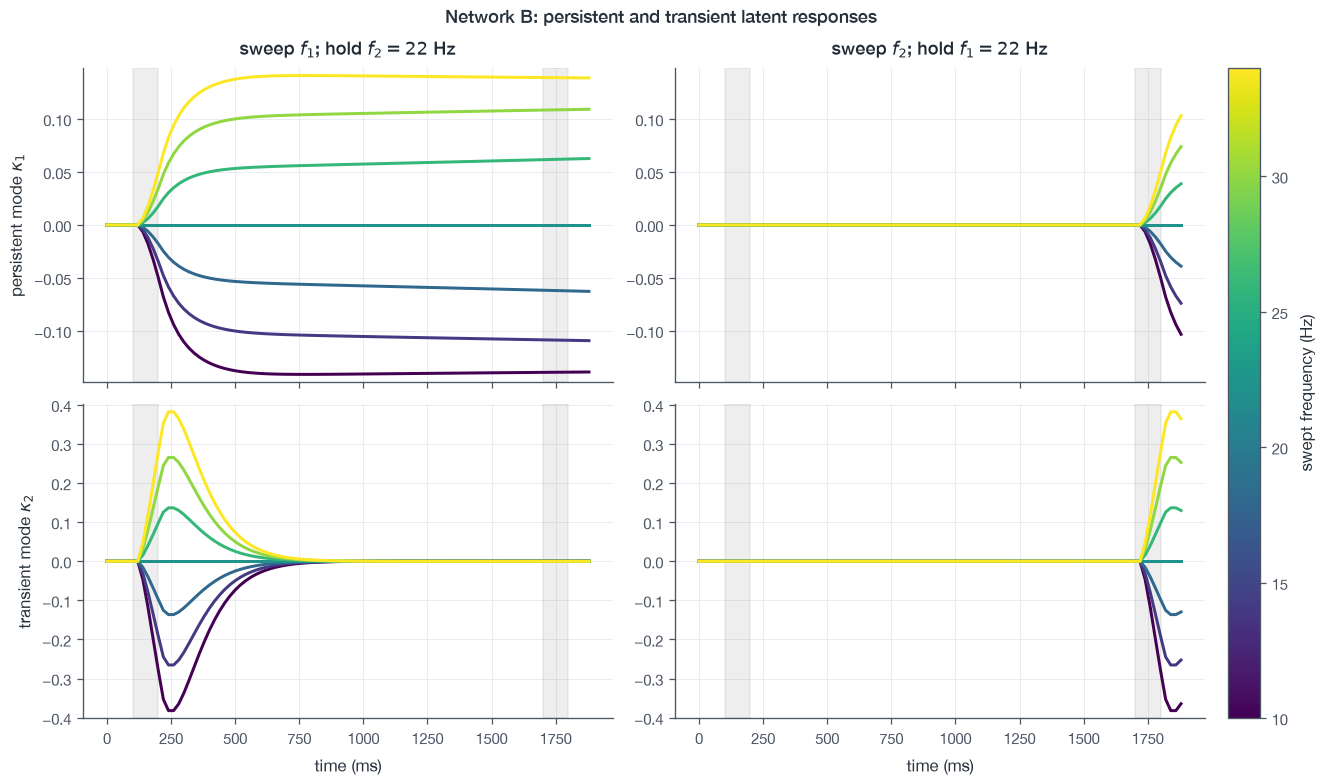

In [23]:
persistent_delay = 75
first_frequency_sweep, second_frequency_sweep = (
    memory_task.frequency_sweeps()
)
first_mode_inputs, _, _ = memory_task.make_variable_delay_trials(
    first_frequency_sweep,
    np.full(len(first_frequency_sweep), persistent_delay),
)
second_mode_inputs, _, _ = memory_task.make_variable_delay_trials(
    second_frequency_sweep,
    np.full(len(second_frequency_sweep), persistent_delay),
)
persistent_basis = np.column_stack(
    (persistent_m, persistent_model.I.detach().numpy())
)
_, _, first_mode_coordinates = analysis.simulate_and_project(
    persistent_model,
    first_mode_inputs,
    persistent_basis,
)
_, _, second_mode_coordinates = analysis.simulate_and_project(
    persistent_model,
    second_mode_inputs,
    persistent_basis,
)

second_start = (
    memory_task.VARIABLE_FIXATION_STEPS
    + memory_task.VARIABLE_STIMULUS_STEPS
    + persistent_delay
)
second_stop = second_start + memory_task.VARIABLE_STIMULUS_STEPS
plotting.plot_latent_sweeps(
    first_mode_coordinates[..., :2],
    second_mode_coordinates[..., :2],
    memory_task.FREQUENCIES,
    time_values=20 * np.arange(second_stop + 5),
    window_spans=(
        (
            20 * memory_task.VARIABLE_FIXATION_STEPS,
            20
            * (
                memory_task.VARIABLE_FIXATION_STEPS
                + memory_task.VARIABLE_STIMULUS_STEPS
            ),
        ),
        (20 * second_start, 20 * second_stop),
    ),
    column_titles=(
        r"sweep $f_1$; hold $f_2=22$ Hz",
        r"sweep $f_2$; hold $f_1=22$ Hz",
    ),
    row_labels=(
        r"persistent mode $\kappa_1$",
        r"transient mode $\kappa_2$",
    ),
    title="Network B: persistent and transient latent responses",
)
plt.show()


The fitted loop gains are $1.011$ and $-0.218$, corresponding to
zero-state flow eigenvalues $0.011$ and $-1.218$. The first mode is
near marginal and retains the first stimulus through the delay; the second
responds to the later stimulus and contracts quickly.

#### Gaussian reconstruction

We repeat the reconstruction in Network B's real-mode basis. Scores are
reported at delays of 500, 1000, 1500, and 2000 ms.

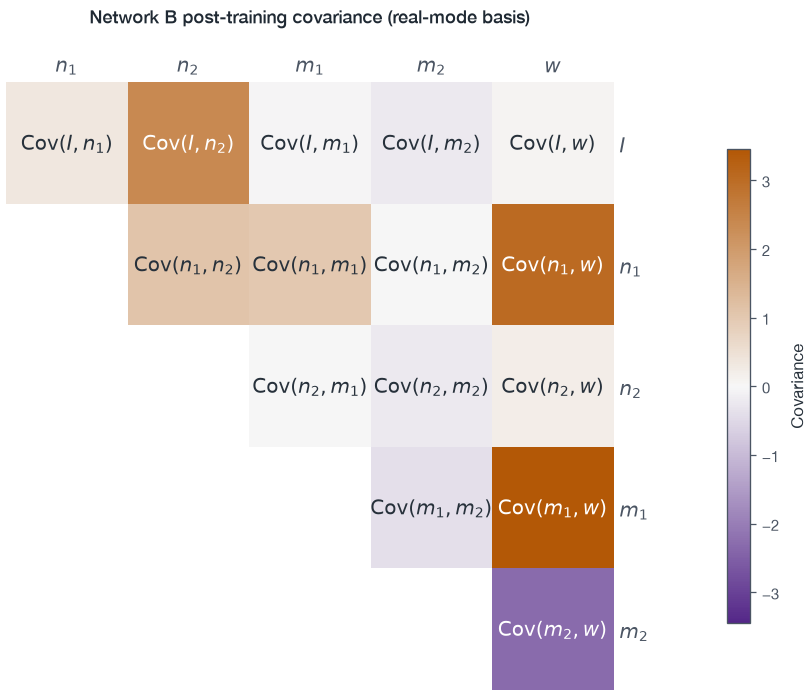

{'Cov(n_1, I)': 0.32751234164574583,
 'Cov(n_2, I)': 2.354993056569698,
 'Cov(m_1, w)': 3.449815775681174,
 'Cov(m_2, w)': -2.298503258096229}

In [24]:
persistent_vectors = analysis.connectivity_vectors(
    persistent_model,
    m=persistent_m,
    n=persistent_n,
)
persistent_names = tuple(persistent_vectors)
(
    persistent_loading_mean,
    persistent_loading_covariance,
) = analysis.fit_loading_gaussian(persistent_vectors)

plotting.plot_connectivity_covariance(
    persistent_names,
    persistent_loading_covariance,
    title="Network B post-training covariance (real-mode basis)",
)
plt.show()

persistent_couplings = analysis.named_covariances(
    persistent_names,
    persistent_loading_covariance,
    (
        ("n_1", "I"),
        ("n_2", "I"),
        ("m_1", "w"),
        ("m_2", "w"),
    ),
)
persistent_couplings


In [25]:
persistent_sampled_networks = analysis.sample_low_rank_rnns(
    persistent_names,
    persistent_loading_mean,
    persistent_loading_covariance,
    num_networks=NUM_GAUSSIAN_NETWORKS,
    num_neurons=NUM_UNITS,
    rng=np.random.default_rng(BASE_SEED + 31),
)
persistent_sampled_mses_by_delay = np.array(
    [
        analysis.variable_delay_mses(
            network,
            memory_grid_pairs,
            probe_delays,
        )
        for network in persistent_sampled_networks
    ]
)
persistent_sampled_worst_mses = (
    persistent_sampled_mses_by_delay.max(axis=1)
)

print(
    "Finite Gaussian RNN worst-delay MSE, median [range]: "
    f"{np.median(persistent_sampled_worst_mses):.4f} "
    f"[{persistent_sampled_worst_mses.min():.4f}, "
    f"{persistent_sampled_worst_mses.max():.4f}]"
)


Finite Gaussian RNN worst-delay MSE, median [range]: 0.0453 [0.0064, 0.1117]


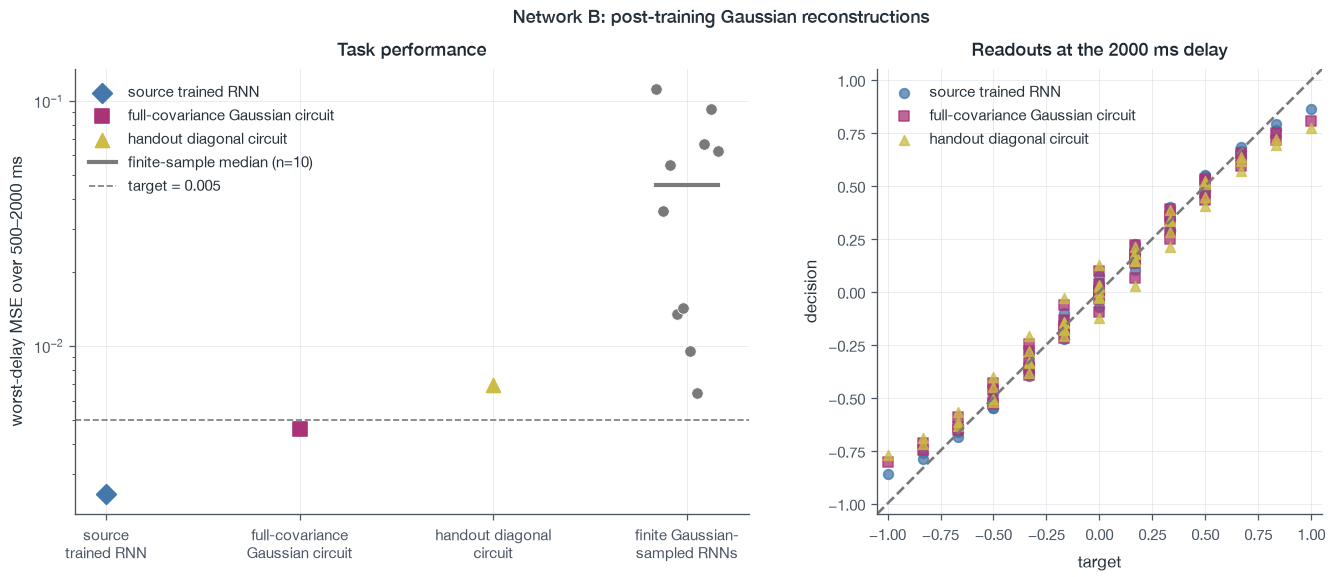

Source MSE by delay:   [0.001771 0.001839 0.002133 0.002496]
Full circuit by delay: [0.003291 0.003553 0.004079 0.004612]
Diagonal by delay:     [0.005701 0.005895 0.006431 0.006946]


In [26]:
(
    persistent_reduced_mses,
    _,
    persistent_reduced_decisions_by_delay,
) = analysis.variable_delay_metrics(
    lambda inputs: mean_field.simulate_gaussian_circuit(
        inputs,
        persistent_names,
        persistent_loading_mean,
        persistent_loading_covariance,
        step_size=persistent_model.step_size,
    )[0],
    memory_grid_pairs,
    probe_delays,
)
(
    persistent_diagonal_mses,
    _,
    persistent_diagonal_decisions_by_delay,
) = analysis.variable_delay_metrics(
    lambda inputs: mean_field.simulate_diagonal_circuit(
        inputs,
        persistent_names,
        persistent_loading_covariance,
        step_size=persistent_model.step_size,
    )[0],
    memory_grid_pairs,
    probe_delays,
)

plotting.plot_gaussian_pipeline(
    persistent_probe_mses.max(),
    persistent_reduced_mses.max(),
    persistent_diagonal_mses.max(),
    persistent_sampled_worst_mses,
    memory_grid_targets,
    persistent_probe_decisions_by_delay[-1],
    persistent_reduced_decisions_by_delay[-1],
    persistent_diagonal_decisions_by_delay[-1],
    threshold=TASK_MSE_THRESHOLD,
    title="Network B: post-training Gaussian reconstructions",
    score_label="worst-delay MSE over 500–2000 ms",
    readout_title="Readouts at the 2000 ms delay",
)
plt.show()

assert persistent_reduced_mses.max() < TASK_MSE_THRESHOLD
print("Source MSE by delay:  ", np.round(persistent_probe_mses, 6))
print("Full circuit by delay:", np.round(persistent_reduced_mses, 6))
print("Diagonal by delay:    ", np.round(persistent_diagonal_mses, 6))


The trained network and full-covariance circuit remain below the $0.005$
threshold at all four delays. The diagonal circuit is close
($0.0053$–$0.0062$), while every finite Gaussian sample is above
threshold.

### 2.4 Matched evaluation

The preceding reconstruction scores use each network's native protocol.
For a direct comparison, both trained models now receive the same 49
frequency pairs, targets, and decision windows on the fixed schedule and
at every 20 ms delay from 500 to 2000 ms.

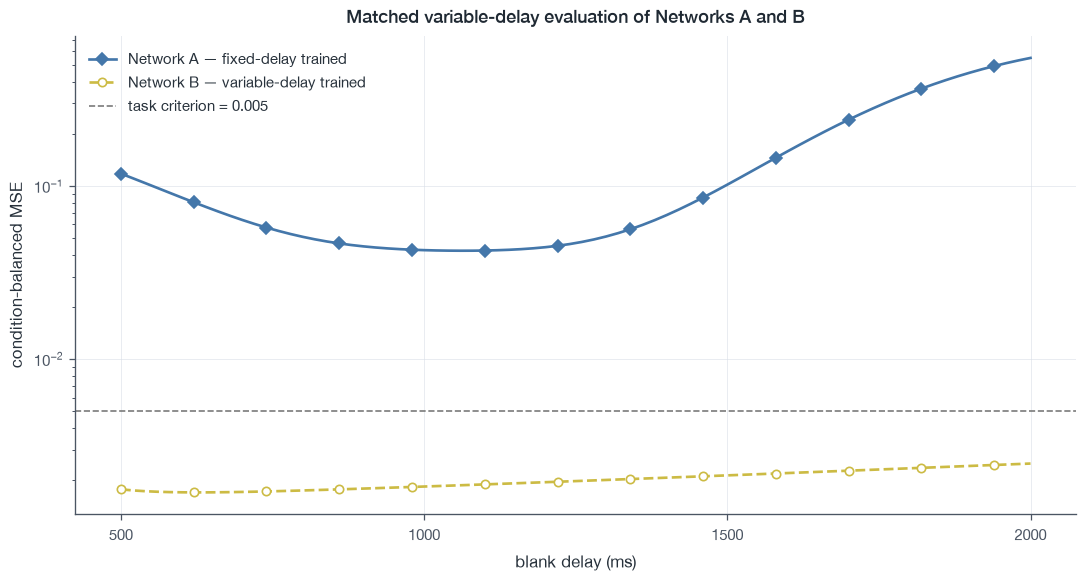

Fixed schedule MSE, A / B: 0.000373 / 0.049297
Variable-delay mean / worst MSE, A: 0.143302 / 0.548195
Variable-delay mean / worst MSE, B: 0.002014 / 0.002496


In [27]:
persistent_fixed_outputs, _ = analysis.run_model(
    persistent_model,
    memory_grid_inputs,
)
persistent_fixed_decisions = analysis.decision_values(
    persistent_fixed_outputs,
    MEMORY_DECISION_STEPS,
)
persistent_fixed_mse, _ = analysis.regression_metrics(
    persistent_fixed_decisions,
    memory_grid_targets,
)

MATCHED_DELAYS = memory_task.DELAYS.copy()
matched_delay_ms = 20 * MATCHED_DELAYS
matched_variable_a_mses = analysis.variable_delay_mses(
    oscillatory_model,
    memory_grid_pairs,
    MATCHED_DELAYS,
)
matched_variable_b_mses = analysis.variable_delay_mses(
    persistent_model,
    memory_grid_pairs,
    MATCHED_DELAYS,
)
matched_probe_indices = probe_delays - MATCHED_DELAYS[0]

assert np.allclose(
    matched_variable_b_mses[matched_probe_indices],
    persistent_probe_mses,
)
plotting.plot_matched_network_comparison(
    matched_delay_ms,
    matched_variable_a_mses,
    matched_variable_b_mses,
    threshold=TASK_MSE_THRESHOLD,
)
plt.show()

print(
    "Fixed schedule MSE, A / B:",
    f"{oscillatory_mse:.6f} / {persistent_fixed_mse:.6f}",
)
print(
    "Variable-delay mean / worst MSE, A:",
    f"{matched_variable_a_mses.mean():.6f} / "
    f"{matched_variable_a_mses.max():.6f}",
)
print(
    "Variable-delay mean / worst MSE, B:",
    f"{matched_variable_b_mses.mean():.6f} / "
    f"{matched_variable_b_mses.max():.6f}",
)


Network A is better on its fixed schedule
($0.000788$ versus $0.058812$). Across the matched variable-delay
sweep, A has mean/worst MSE $0.114628/0.303430$, while B has
$0.001945/0.002446$. Because the models also differ in initialization,
stimulus duration, and training frequencies, this is a robustness
comparison rather than a controlled test of initialization.

### 2.5 Reconstruction summary

The table uses each network's native evaluation protocol, so it summarizes
reconstruction fidelity rather than a direct comparison between A and B.

In [28]:
oscillatory_sample_successes = np.sum(
    oscillatory_sampled_mses < TASK_MSE_THRESHOLD
)
persistent_sample_successes = np.sum(
    persistent_sampled_worst_mses < TASK_MSE_THRESHOLD
)

rank_two_summary = f'''
| Network | Learned dynamics | Source RNN | Finite Gaussian RNNs | Full circuit | Diagonal circuit |
|---|---|---:|---:|---:|---:|
| A | fixed-delay rotation | {oscillatory_mse:.4f} | median {np.median(oscillatory_sampled_mses):.3f}; {oscillatory_sample_successes}/{NUM_GAUSSIAN_NETWORKS} pass | {oscillatory_reduced_mse:.4f} | {oscillatory_diagonal_mse:.4f} |
| B | persistent / transient modes | worst {persistent_probe_mses.max():.4f} | median worst {np.median(persistent_sampled_worst_mses):.3f}; {persistent_sample_successes}/{NUM_GAUSSIAN_NETWORKS} pass | worst {persistent_reduced_mses.max():.4f} | worst {persistent_diagonal_mses.max():.4f} |
'''
display(Markdown(rank_two_summary))



| Network | Learned dynamics | Source RNN | Finite Gaussian RNNs | Full circuit | Diagonal circuit |
|---|---|---:|---:|---:|---:|
| A | fixed-delay rotation | 0.0004 | median 0.084; 1/10 pass | 0.0195 | 0.6948 |
| B | persistent / transient modes | worst 0.0025 | median worst 0.045; 0/10 pass | worst 0.0046 | worst 0.0069 |


## 3. Conclusions

- The rank-one RNN integrates noisy evidence in a two-dimensional
  $\operatorname{span}\{m,I\}$ subspace and stores the decision in two
  stable fixed points. Gaussian resamples and the mean-field circuit both
  retain 100% sign accuracy.
- Fixed-delay training produces a slowly decaying rotation. This model is
  accurate on its native schedule but sensitive to changes in delay.
- Variable-delay training produces a near-marginal memory mode and a
  contracting comparison mode. The trained model remains below threshold
  from 500 to 2000 ms.
- Rank-two Gaussian reconstruction is sensitive to finite sampling. The
  full covariance preserves substantially more behavior than the diagonal
  approximation, especially for the oscillatory network.